# LLM Experiment-2

Blood Cancer Detection with Explainable AI Using
Deep Learning

In [3]:
import kagglehub

path = kagglehub.dataset_download("sizlingdhairya1/all-idb-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'all-idb-images' dataset.
Path to dataset files: /kaggle/input/all-idb-images


In [4]:
!pip install transformers datasets evaluate accelerate -U
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from transformers import AutoImageProcessor, AutoModelForImageClassification, TrainingArguments, Trainer
from datasets import load_dataset
import evaluate

In [5]:
dataset = load_dataset("imagefolder", data_dir=path)

dataset = dataset["train"].train_test_split(test_size=0.2)

labels = dataset["train"].features["label"].names
label2id, id2label = {label: i for i, label in enumerate(labels)}, {i: label for i, label in enumerate(labels)}

Resolving data files:   0%|          | 0/150 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [6]:
checkpoint = "facebook/convnext-tiny-224"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

def transform(example_batch):
    inputs = image_processor([x.convert("RGB") for x in example_batch["image"]], return_tensors="pt")
    inputs["labels"] = example_batch["label"]
    return inputs

prepared_ds = dataset.with_transform(transform)

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

The image processor of type `ConvNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [8]:
num_classes = len(labels)
print(f"Detected {num_classes} classes: {labels}")

model = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=num_classes,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True
)

Detected 3 classes: ['L1', 'L2', 'L3']


pytorch_model.bin:   0%|          | 0.00/114M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/182 [00:00<?, ?it/s]

ConvNextForImageClassification LOAD REPORT from: facebook/convnext-tiny-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([3])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [11]:
from transformers import TrainingArguments, Trainer

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./blood_cancer_model",
    remove_unused_columns=False,
    eval_strategy="epoch",
    learning_rate=1e-3,
    per_device_train_batch_size=32,
    num_train_epochs=20,
    logging_steps=10,
    load_best_model_at_end=True,
    save_strategy="epoch"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=prepared_ds["train"],
    eval_dataset=prepared_ds["test"],
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.277234,1.000000
2,No log,0.028514,1.000000
3,0.396858,0.002278,1.000000
4,0.396858,0.000760,1.000000
5,0.002223,0.000523,1.000000
6,0.002223,0.000397,1.000000
7,0.002223,0.000304,1.000000
8,0.000327,0.000207,1.000000
9,0.000327,0.000143,1.000000
10,0.000134,0.000112,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=80, training_loss=0.04997600549904746, metrics={'train_runtime': 233.2009, 'train_samples_per_second': 10.292, 'train_steps_per_second': 0.343, 'total_flos': 6.0307999137792e+16, 'train_loss': 0.04997600549904746, 'epoch': 20.0})

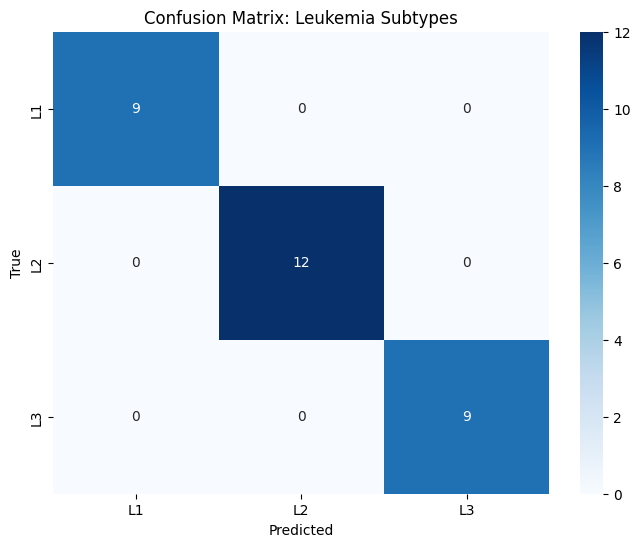


--- Performance Metrics ---
              precision    recall  f1-score   support

          L1       1.00      1.00      1.00         9
          L2       1.00      1.00      1.00        12
          L3       1.00      1.00      1.00         9

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

output = trainer.predict(prepared_ds["test"])
y_pred = np.argmax(output.predictions, axis=1)
y_true = output.label_ids

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Leukemia Subtypes')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("\n--- Performance Metrics ---")
print(classification_report(y_true, y_pred, target_names=labels))